In [1]:
import psycopg2
import pandas as pd
#pip install psycopg2-binary
#https://adsai.buas.nl/Year1/BlockD/assets/code_book.html

db_params = {
    'host': '194.171.191.226',
    'port': '6379',
    'database': 'postgres',
    'user': 'group15',
    'password': 'blockd_2024group15_73'
}

con = psycopg2.connect(**db_params)

In [2]:
sql = '''
SELECT *
FROM data_lake.safe_driving
'''

cur = con.cursor()
cur.execute(sql)

data = cur.fetchall()

columns_names = [col.name for col in cur.description]

cur.close()
pd.set_option('display.max_columns', None)
df_safe_driving = pd.DataFrame(data, columns = columns_names)

In [3]:
display(df_safe_driving.head(10))

,eventid,event_start,event_end,duration_seconds,latitude,longitude,speed_kmh,end_speed_kmh,maxwaarde,category,incident_severity,is_valid,road_segment_id,road_manager_type,road_number,road_name,place_name,municipality_name,road_manager_name
0,98982708,2022-08-22 12:46:49.400,2022-08-22 12:46:51.600,2.2,51.59279,4.756620,63.014507,57.733300,0.720986,HARSH CORNERING,HC1,False,600915496,G,,Lunetstraat,Breda,Breda,Breda
1,98989116,2022-08-22 18:43:44.500,2022-08-22 18:43:46.000,1.5,51.55037,4.727850,40.233600,28.968191,0.804672,HARSH CORNERING,HC1,True,218191003,G,,Rijsbergseweg,Breda,Breda,Breda
2,98989648,2022-08-22 17:06:13.000,2022-08-22 17:06:25.000,12.0,51.57913,4.739310,43.272070,41.641277,46.540880,SPEED,SP1,True,220198051,G,,Nieuwe Heilaarstraat,Breda,Breda,Breda
3,99047526,2022-08-22 14:46:56.500,2022-08-22 14:46:57.200,0.7,51.59296,4.828143,14.484096,19.312128,0.828812,ACCELERATING,HA1,False,600756786,G,,Tilburgseweg,Breda,Breda,Breda
4,99072695,2022-08-22 20:09:20.600,2022-08-22 20:09:22.800,2.2,51.57927,4.736780,35.730060,30.423650,0.738689,HARSH CORNERING,HC1,True,219198059,G,,Nieuwe Heilaarstraat,Breda,Breda,Breda
5,99100044,2022-08-22 18:35:17.100,2022-08-22 18:35:17.600,0.5,51.58895,4.820646,27.360039,11.880020,1.038027,BRAKING,HB1,True,600940844,G,,Heerbaan,Breda,Breda,Breda
6,99054794,2022-08-22 13:25:22.000,2022-08-22 13:25:23.100,1.1,51.57242,4.779960,47.714474,46.134083,1.025152,BRAKING,HB1,False,600121504,G,,Johan Willem Frisolaan,Breda,Breda,Breda
7,98992770,2022-08-22 13:42:42.400,2022-08-22 13:42:44.600,2.2,51.58176,4.826755,28.968191,38.624256,0.854562,HARSH CORNERING,HC1,True,231198030,G,,Franklin Rooseveltlaan,Breda,Breda,Breda
8,99065861,2022-08-22 15:37:22.000,2022-08-22 15:37:42.000,20.0,51.56866,4.749422,82.076546,85.295235,85.295235,SPEED,SP1,True,600750206,G,,Graaf Engelbertlaan,Breda,Breda,Breda
9,98985230,2022-08-22 13:04:54.000,2022-08-22 13:05:00.000,6.0,51.60189,4.735610,82.998140,81.871340,85.086140,SPEED,SP1,True,600892614,G,,Backer en Ruebweg,Breda,Breda,Breda


Creating new speeding table

In [4]:
only_speeding = df_safe_driving['category'] == 'SPEED'

df_speeding = df_safe_driving[only_speeding].copy()

df_speeding = df_speeding[['maxwaarde', 'road_name', 'place_name']]

display(df_speeding.head(10))

,maxwaarde,road_name,place_name
2,46.540880,Nieuwe Heilaarstraat,Breda
8,85.295235,Graaf Engelbertlaan,Breda
9,85.086140,Backer en Ruebweg,Breda
11,74.808120,Graaf Engelbertlaan,Breda
13,66.103310,Lunetstraat,Breda
20,70.740110,Graaf Engelbertlaan,Breda
22,89.578950,Franklin Rooseveltlaan,Breda
24,77.248510,Baanzicht,Breda
27,66.492100,Lunetstraat,Breda
30,74.304120,Terheijdenseweg,Breda


Importing (better) accidents table

In [5]:
sql = '''
SELECT *
FROM data_lake.accident_data_17_23
'''
cur = con.cursor()
cur.execute(sql)

data = cur.fetchall()

columns_names = [col.name for col in cur.description]

cur.close()

pd.set_option('display.max_columns', None)
df_accident_data = pd.DataFrame(data, columns = columns_names)
display(df_accident_data.head(10))

,Year,Accident severity,municipality,town,First Mode of Transport,Second mode of Transport,Area Type,Light condition,Road Location,Road condition,Road surface,Road situation,Speed limit,street,weather,accidents
0,2017,Fatal,Breda,BREDA,Car,Pedestrian,Urban area,Darkness,Intersection,Wet/damp,Brick,Bend,30 km/h,Valkeniersplein,Rain,1
1,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Intersection,Wet/damp,Brick,Intersection - 4 arms,50 km/h,Markendaalseweg,Dry,1
2,2017,Fatal,Breda,BREDA,Lorry,Other,Urban area,Daylight,Road section,Dry,Asphalt (other),Straight road,50 km/h,Academiesingel,Dry,1
3,2017,Injured,Breda,BAVEL,Car,Lorry,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Bend,120 km/h,KP ST.ANNABOSCH,Dry,1
4,2017,Injured,Breda,BAVEL,Car,Other,Rural area,Darkness,Road section,Wet/damp,Porous asphalt,Straight road,130 km/h,RYKSWG,Rain,1
5,2017,Injured,Breda,BAVEL,Delivery van,Car,Rural area,Darkness,Road section,Wet/damp,Asphalt (other),Straight road,80 km/h,Gilzeweg,Rain,1
6,2017,Injured,Breda,BREDA,Bicycle,Motorcycle,Urban area,Daylight,Intersection,Dry,Asphalt (other),Intersection - 4 arms,50 km/h,Nieuwe Kadijk,Dry,1
7,2017,Injured,Breda,BREDA,Bicycle,Other,Urban area,Daylight,Intersection,Dry,Asphalt (other),Intersection - 4 arms,30 km/h,Rithsestraat,Dry,1
8,2017,Injured,Breda,BREDA,Bicycle,Other,Urban area,Daylight,Intersection,Dry,Brick,Straight road,Unknown,Steenbroek,Dry,1
9,2017,Injured,Breda,BREDA,Bicycle,Other,Unknown,Darkness,Road section,Unknown,Unknown,Unknown,50 km/h,Achter Emer,Unknown,1


Creating new speed limits table

In [6]:
df_speed_limits = df_accident_data[['Speed limit', 'street', 'town']]
display(df_speed_limits.head(10))
display(df_speeding.head(10))

,Speed limit,street,town
0,30 km/h,Valkeniersplein,BREDA
1,50 km/h,Markendaalseweg,BREDA
2,50 km/h,Academiesingel,BREDA
3,120 km/h,KP ST.ANNABOSCH,BAVEL
4,130 km/h,RYKSWG,BAVEL
5,80 km/h,Gilzeweg,BAVEL
6,50 km/h,Nieuwe Kadijk,BREDA
7,30 km/h,Rithsestraat,BREDA
8,Unknown,Steenbroek,BREDA
9,50 km/h,Achter Emer,BREDA


,maxwaarde,road_name,place_name
2,46.540880,Nieuwe Heilaarstraat,Breda
8,85.295235,Graaf Engelbertlaan,Breda
9,85.086140,Backer en Ruebweg,Breda
11,74.808120,Graaf Engelbertlaan,Breda
13,66.103310,Lunetstraat,Breda
20,70.740110,Graaf Engelbertlaan,Breda
22,89.578950,Franklin Rooseveltlaan,Breda
24,77.248510,Baanzicht,Breda
27,66.492100,Lunetstraat,Breda
30,74.304120,Terheijdenseweg,Breda


Adding speed limit column to speeding df and normalizing it to numerical values, droping rows with missing values

In [7]:
# Normalization
df_speeding['place_name'] = df_speeding['place_name'].str.upper()

# Iterating over each row in df_speeding
for index, row in df_speeding.iterrows():
    matching_row = df_speed_limits[(df_speed_limits['street'] == row['road_name']) & (df_speed_limits['town'] == row['place_name'])]
    
    if not matching_row.empty:
        speed_limit = matching_row['Speed limit'].iloc[0]
        df_speeding.at[index, 'Speed limit'] = speed_limit

display(df_speeding.head(10))

,maxwaarde,road_name,place_name,Speed limit
2,46.540880,Nieuwe Heilaarstraat,BREDA,30 km/h
8,85.295235,Graaf Engelbertlaan,BREDA,50 km/h
9,85.086140,Backer en Ruebweg,BREDA,70 km/h
11,74.808120,Graaf Engelbertlaan,BREDA,50 km/h
13,66.103310,Lunetstraat,BREDA,50 km/h
20,70.740110,Graaf Engelbertlaan,BREDA,50 km/h
22,89.578950,Franklin Rooseveltlaan,BREDA,50 km/h
24,77.248510,Baanzicht,BREDA,Unknown
27,66.492100,Lunetstraat,BREDA,50 km/h
30,74.304120,Terheijdenseweg,BREDA,50 km/h


Converting speed limit to float

In [8]:
df_speeding.dropna(subset=['Speed limit'], inplace=True)

df_speeding['Speed limit'] = df_speeding['Speed limit'].str.strip()
df_speeding = df_speeding[df_speeding['Speed limit'].str.contains('km/h')]
df_speeding['Speed limit'] = df_speeding['Speed limit'].str.extract(r'(\d+)').astype(float)
df_speeding['Speed limit'] = df_speeding['Speed limit'].astype(float)

display(df_speeding.head(10))

,maxwaarde,road_name,place_name,Speed limit
2,46.540880,Nieuwe Heilaarstraat,BREDA,30.0
8,85.295235,Graaf Engelbertlaan,BREDA,50.0
9,85.086140,Backer en Ruebweg,BREDA,70.0
11,74.808120,Graaf Engelbertlaan,BREDA,50.0
13,66.103310,Lunetstraat,BREDA,50.0
20,70.740110,Graaf Engelbertlaan,BREDA,50.0
22,89.578950,Franklin Rooseveltlaan,BREDA,50.0
27,66.492100,Lunetstraat,BREDA,50.0
30,74.304120,Terheijdenseweg,BREDA,50.0
37,86.396540,Graaf Engelbertlaan,BREDA,50.0


Droping place name column and leaving only breda streets

In [9]:
df_speeding = df_speeding[df_speeding['place_name'] == 'BREDA']

df_speeding = df_speeding.drop(columns=['place_name'])

display(df_speeding)

,maxwaarde,road_name,Speed limit
2,46.540880,Nieuwe Heilaarstraat,30.0
8,85.295235,Graaf Engelbertlaan,50.0
9,85.086140,Backer en Ruebweg,70.0
11,74.808120,Graaf Engelbertlaan,50.0
13,66.103310,Lunetstraat,50.0
...,...,...,...
964467,70.811134,Ettensebaan,50.0
964469,72.306120,Hazeldonk,50.0
964470,97.488170,Lunetstraat,50.0
964476,70.009315,Claudius Prinsenlaan,50.0


reanaming speed limit column

In [10]:
df_speeding['speed_limit'] = df_speeding['Speed limit']

df_speeding = df_speeding.drop(columns=['Speed limit'])

display(df_speeding)

,maxwaarde,road_name,speed_limit
2,46.540880,Nieuwe Heilaarstraat,30.0
8,85.295235,Graaf Engelbertlaan,50.0
9,85.086140,Backer en Ruebweg,70.0
11,74.808120,Graaf Engelbertlaan,50.0
13,66.103310,Lunetstraat,50.0
...,...,...,...
964467,70.811134,Ettensebaan,50.0
964469,72.306120,Hazeldonk,50.0
964470,97.488170,Lunetstraat,50.0
964476,70.009315,Claudius Prinsenlaan,50.0


pushing speeding table to our warehouse

In [11]:
import psycopg2

cur = con.cursor()

try:
    create_table_query = """
    CREATE TABLE IF NOT EXISTS group15_warehouse.speeding (
        maxwaarde FLOAT,
        road_name TEXT,
        speed_limit FLOAT
    );
    """
    cur.execute(create_table_query)

    con.commit()
    for index, row in df_speeding.iterrows():
        query = """
        INSERT INTO group15_warehouse.speeding(maxwaarde, road_name, speed_limit)
        VALUES (%s, %s, %s);
        """
        values = (row['maxwaarde'], row['road_name'], row['speed_limit'])
        cur.execute(query, values)
    
    con.commit()

except Exception as e:
    print("Error:", e)
    con.rollback()

finally:
    print('data uploaded')
    cur.close()
    

data uploaded


Ploting strees with the hishest speeding rate

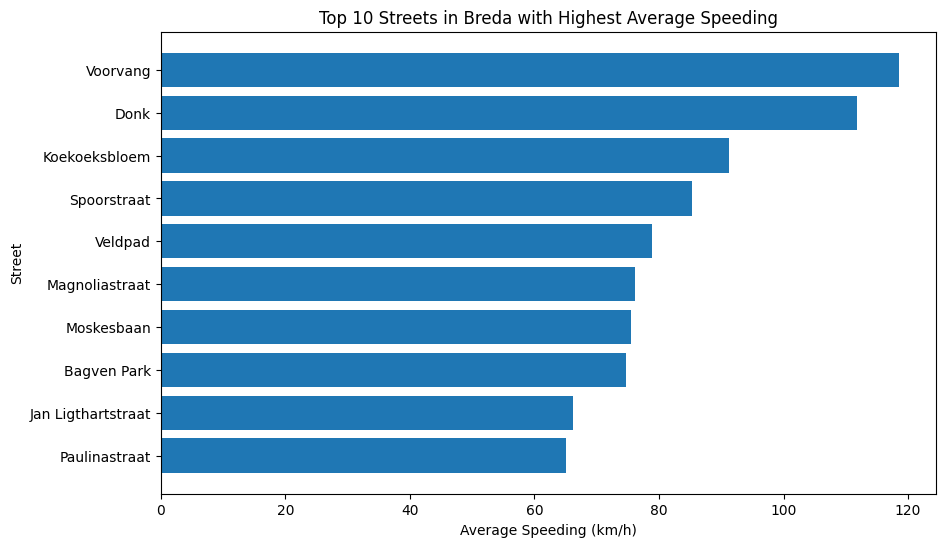

In [16]:
import matplotlib.pyplot as plt

# Calculating the speeding for each row
df_speeding['speeding'] = df_speeding['maxwaarde'] - df_speeding['speed_limit']

# Grouping by road_name
average_speeding = df_speeding.groupby(['road_name']).agg(average_speeding=('speeding', 'mean'))
average_speeding.reset_index(inplace=True)

top_10_speeding_streets = average_speeding.sort_values(by='average_speeding', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_speeding_streets['road_name'], top_10_speeding_streets['average_speeding'])
plt.xlabel('Average Speeding (km/h)')
plt.ylabel('Street')
plt.title('Top 10 Streets in Breda with Highest Average Speeding')
plt.gca().invert_yaxis()
plt.show()
